**Write the names of all group members (max. 5 members)**:
- Avesta Khaliqi
- Maximilian Flug
- Minghhan Yang
- Ken Rölli

When submitting your work, please follow closely the template below.

# Exercise 1 (Poisson GLM)

### Question 1.a

In [1]:
import pandas as pd
from sklearn.model_selection  import train_test_split, GridSearchCV
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.base import clone
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_poisson_deviance
import matplotlib.pyplot as plt

from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
import torch

from sklearn import tree, ensemble
from sklearn.model_selection import KFold
from torch.utils.data import Subset

In [45]:
import joblib # For saving and loading models, especially since Random Forest takes >4 hours to cross-validate.

save_expensive_models = False
load_expensive_models = False
perform_model_comparison = True
N_COMPARISONS = 10

MODEL_FOLDER_NAME = "models"

# Create the necessary folder if it does not exist
if save_expensive_models or load_expensive_models:
    from pathlib import Path
    Path(MODEL_FOLDER_NAME).mkdir(parents=True, exist_ok=True)

In [3]:
# Read csv file `freMTPL2freq.csv` (e.g. use pandas)
df = pd.read_csv("freMTPL2freq.csv", sep=";", decimal=",") # decimal="," is necessary, since read_csv() expects "." as decimal separator by default

In [ ]:
np.random.seed(1000)

TRAIN_SIZE = 0.9
# Train-test split
df_train, df_test = train_test_split(df, train_size=TRAIN_SIZE)

# Train a Poisson GLM
# You can use sklearn.linear_model.Poisson_Regressor

continuous_features = []
discrete_features = ["VehPower", "VehAge", "DrivAge", "BonusMalus", "Density"]
categorical_features = ["VehBrand", "VehGas", "Region"]

all_features = continuous_features + discrete_features + categorical_features

X_train = df_train[all_features]
X_test = df_test[all_features]


y_train = df_train["ClaimNb"] / df_train["Exposure"]
y_test = df_test["ClaimNb"] / df_test["Exposure"]

exposure_train = df_train["Exposure"]
exposure_test = df_test["Exposure"]

claim_number_train = df_train["ClaimNb"]
claim_number_test = df_test["ClaimNb"]

# Print MAE, MSE and loss on train and test data sets
def calculate_poisson_metrics(y_true, y_pred, exposure):
    # We weight MAE and MSE by exposure to account for varying exposure times -> observations with higher exposure should contribute more to the error metrics.
    mae = mean_absolute_error(y_true, y_pred, sample_weight=exposure)
    mse = mean_squared_error(y_true, y_pred, sample_weight=exposure)
    
    # Looking at the documentation https://scikit-learn.org/stable/modules/model_evaluation.html#mean-tweedie-deviance,
    # we see that the third loss that we want to compute is just equal to the mean_poisson_deviance where we 
    # set sample_weight to the exposure.
    exposure_weighted_poisson_deviance = mean_poisson_deviance(y_true, y_pred, sample_weight=exposure)
    return mae, mse, exposure_weighted_poisson_deviance

def print_poisson_metrics(name, mae, mse, exposure_weighted_poisson_deviance):
    print(f"{name} Metrics:\nMAE: {mae:.3f}, MSE: {mse:.3f}, L: {exposure_weighted_poisson_deviance:.3f}\n")

# Standardize the continuous and discrete features
# One-hot encode the categorical features

print(f"Number of NAs: {df.isna().sum().sum()}")

# We have no NA values, so no need to handle them
standardize_one_hot_transformer = ColumnTransformer(
    transformers=[
        ("standardize", StandardScaler(), continuous_features + discrete_features),
        ("one-hot encode", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

Number of NAs: 0


In [ ]:
poisson_pipeline = Pipeline(
    steps=[
        ("transform", standardize_one_hot_transformer),
        ("poisson_glm", PoissonRegressor(alpha=0.0))
    ]
)

poisson_pipeline.fit(X_train, y_train, poisson_glm__sample_weight=exposure_train)

y_pred_train = poisson_pipeline.predict(X_train)
y_pred_test = poisson_pipeline.predict(X_test)

poisson_1_metrics_train = calculate_poisson_metrics(y_train, y_pred_train, exposure_train)
poisson_1_metrics_test = calculate_poisson_metrics(y_test, y_pred_test, exposure_test)

print_poisson_metrics("Poisson GLM 1 Train", *poisson_1_metrics_train) # * unpacks the tuple returned by calculate_... function into mae, mse, L
print_poisson_metrics("Poisson GLM 1 Test", *poisson_1_metrics_test)

Poisson GLM 1 Train Metrics:
MAE: 0.138, MSE: 0.236, L: 0.459

Poisson GLM 1 Test Metrics:
MAE: 0.136, MSE: 0.254, L: 0.452



### Question 1.b

[]

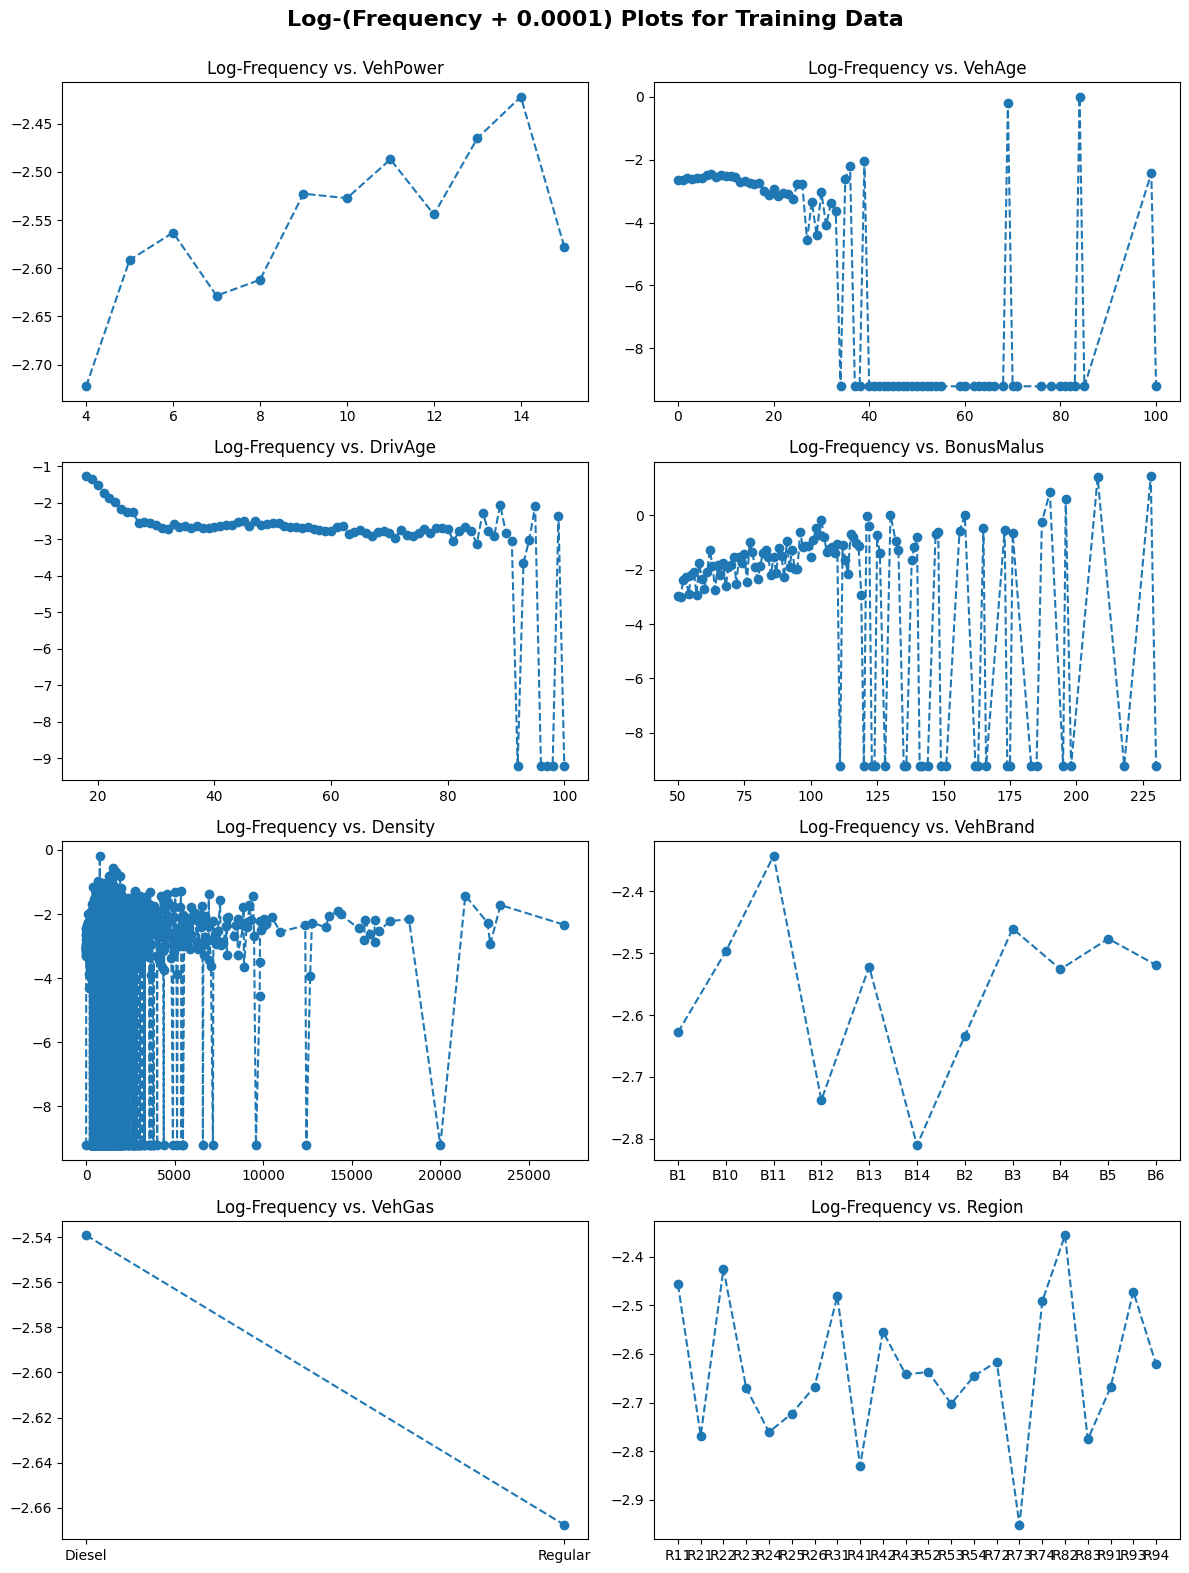

In [31]:
fig, ax = plt.subplots(4, 2, figsize=(12, 16))
ax = ax.flatten()

# Plot the empirical marginal log-frequencies
for idx, feature in enumerate(all_features):
    # We need to group all observations that have the same feature value and then sum their claim number and
    # their exposure. In the end divide them by each other and take the logarithm.

    # We do not want data leakage, so we will only do it on the train data.
    df_train_grouped = df_train.groupby(feature).agg(
        sum_claims=("ClaimNb", "sum"),
        sum_exposure=("Exposure", "sum")
    ).reset_index() # Reset index to 'move the feature that was used for grouping into the df again'

    df_train_grouped["log_frequency"] = np.log(df_train_grouped["sum_claims"] / df_train_grouped["sum_exposure"] + 1e-4)

    ax[idx].plot(df_train_grouped[feature], df_train_grouped["log_frequency"], marker="o", linestyle="--")
    ax[idx].set_title(f'Log-Frequency vs. {feature}')
fig.suptitle("Log-(Frequency + 0.0001) Plots for Training Data", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.plot()

In [9]:
# Propose feature transformations. Justify your choices

We can see that some log-frequency plots have very very low values for $\log(\text{frequency})$. This is due to the fact that all observations for some (rare) categories have not had any claims. So their frequency would technically be zero, and the log(frequency) would be undefined. To avoid this error we added some small margin $10^{-4}$ to the frequency before talking the log, so after taking the log, they have very low negative values (as low as almost -10).

The DrivAge has a very special form. From 18-30 the log frequency seems to steeply decrease, then it increases again up to around 50. From then it decreases slightly again until it gets very unstable after 85. Probably due to a small number of observations / exposures.


For the feature engineering, we tried different approaches.
At first we tried to make the DrivAge and BonusMalus effects a linear spline, allowing different slopes for different DrivAge/BonusMalus intervals. In the log-frequency plots this looks like a reasonable thing to do since the decreases and increases look roughly linear.
However, this approach did not give good results, so we just categorized them into bins.

We categorized DrivAge, BonusMalus and VehAge into the following categories, based on the plots:
- DrivAge: ["<25", "25-30", "30-40", "40-50", "50-60", "60-70", "70-80", "80-90", ">90"]
- BonusMalus: ["<50", "50-75", "75-90", "90-100", "100-110", "110-125", ">125"]
- VehAge: ["<30", "30-40", "40-50", ">50"]
Additionally we log-transformed the Density.

In [7]:
# DRIV_AGE_LOW, DRIV_AGE_HIGH = 30, 90
# def piecewise_DrivAge(df):
#     driv_age = df["DrivAge"]

#     out = pd.DataFrame(index=df.index) # keep the same row index as the input
#     out[f"DrivAge_<{DRIV_AGE_LOW}"] = np.clip(DRIV_AGE_LOW - driv_age, 0, None)
#     out[f"DrivAge_{DRIV_AGE_LOW}-{DRIV_AGE_HIGH}"] = np.clip(driv_age - DRIV_AGE_LOW, 0, DRIV_AGE_HIGH - DRIV_AGE_LOW)
#     out[f"DrivAge_>={DRIV_AGE_HIGH}_Indicator"] = (driv_age >= DRIV_AGE_HIGH).astype(int)
#     return out

def categorize_DrivAge(df):
    driv_age = df["DrivAge"]
    out = pd.DataFrame(index=df.index) # keep the same row index as the input
    out["DrivAge_category"] = pd.cut(driv_age, bins=[0, 25, 30, 40, 50, 60, 70, 80, 90, np.inf], labels=["<25", "25-30", "30-40", "40-50", "50-60", "60-70", "70-80", "80-90", ">90"])
    return out

categorize_DrivAge_pipeline = Pipeline(
    steps=[
        ("categorize", FunctionTransformer(categorize_DrivAge, validate=False)),
        ("one-hot encode", OneHotEncoder(drop="first"))
    ]
)

# BONUS_MALUS_HIGH = 110
# def piecewise_BonusMalus(df):
#     bonus_malus = df["BonusMalus"]

#     out = pd.DataFrame(index=df.index) # keep the same row index as the input
#     out[f"BonusMalus<{BONUS_MALUS_HIGH}"] = np.clip(BONUS_MALUS_HIGH - bonus_malus, 0, None)
#     out[f"BonusMalus_>={BONUS_MALUS_HIGH}_Indicator"] = (bonus_malus > BONUS_MALUS_HIGH).astype(int)
#     return out

def categorize_BonusMalus(df):
    bonus_malus = df["BonusMalus"]
    out = pd.DataFrame(index=df.index) # keep the same row index as the input
    out["BonusMalus_category"] = pd.cut(bonus_malus, bins=[0, 50, 75, 90, 100, 110, 125, np.inf], labels=["<50", "50-75", "75-90", "90-100", "100-110", "110-125", ">125"])
    return out

categorize_BonusMalus_pipeline = Pipeline(
    steps=[
        ("categorize", FunctionTransformer(categorize_BonusMalus, validate=False)),
        ("one-hot encode", OneHotEncoder(drop="first"))
    ]
)

def categorize_VehAge(df):
    veh_age = df["VehAge"]
    out = pd.DataFrame(index=df.index) # keep the same row index as the input
    out["VehAge_category"] = pd.cut(veh_age, bins=[0, 30, 40, 50, np.inf], labels=["<30", "30-40", "40-50", ">50"])
    return out

categorize_VehAge_pipeline = Pipeline(
    steps=[
        ("categorize", FunctionTransformer(categorize_VehAge, validate=False)),
        ("one-hot encode", OneHotEncoder(drop="first"))
    ]
)

log_std_pipeline = Pipeline(
    steps=[
        ("log", FunctionTransformer(np.log1p, validate=False)),
        ("standardize", StandardScaler())
    ]
)



feature_engineering_continuous_features = []
feature_engineering_discrete_features = ["VehPower"]
feature_engineering_categorical_features = ["VehBrand", "VehGas", "Region"]

feature_engineering_transformer = ColumnTransformer(
    transformers=[
        # ("piecewise_DrivAge", FunctionTransformer(piecewise_DrivAge, validate=False), ["DrivAge"]),
        # ("piecewise_BonusMalus", FunctionTransformer(piecewise_BonusMalus, validate=False), ["BonusMalus"]),
        ("categorize_DrivAge", categorize_DrivAge_pipeline, ["DrivAge"]),
        ("categorize_BonusMalus", categorize_BonusMalus_pipeline, ["BonusMalus"]),
        ("categorize_VehAge", categorize_VehAge_pipeline, ["VehAge"]),
        ("log_std_density", log_std_pipeline, ["Density"]),
        ("standardize", StandardScaler(), feature_engineering_continuous_features + feature_engineering_discrete_features),
        ("one-hot encode", OneHotEncoder(drop="first"), feature_engineering_categorical_features)
    ]
)

In [54]:
# From the plots, we see that for the discrete variables BonusMalus, VehAge and DrivAge, it could make sense to group values together.
# VehPower is non-linear as well

feature_engineering_poisson_pipeline = Pipeline(
    steps=[
        ("feature_engineering_transform", feature_engineering_transformer),
        ("feature_engineering_poisson_glm", PoissonRegressor(alpha=0.0, max_iter=500))
    ]
)

feature_engineering_poisson_pipeline.fit(X_train, y_train, feature_engineering_poisson_glm__sample_weight=exposure_train)

y_pred_train = feature_engineering_poisson_pipeline.predict(X_train)
y_pred_test = feature_engineering_poisson_pipeline.predict(X_test)

feature_engineering_poisson_metrics_train = calculate_poisson_metrics(y_train, y_pred_train, exposure_train)
feature_engineering_poisson_metrics_test = calculate_poisson_metrics(y_test, y_pred_test, exposure_test)

print_poisson_metrics("Poisson GLM Feature Engineering Train", *feature_engineering_poisson_metrics_train)
print_poisson_metrics("Poisson GLM Feature Engineering Test", *feature_engineering_poisson_metrics_test)

Poisson GLM Feature Engineering Train Metrics:
MAE: 0.138, MSE: 0.236, L: 0.456

Poisson GLM Feature Engineering Test Metrics:
MAE: 0.136, MSE: 0.245, L: 0.448



We see that the test performance in terms of exposure weighted Poisson deviance ($\mathcal L$) went down to 0.448 (for the basic Poisson GLM it was 0.452).
Since this is just a small improvement, we would like to check whether this was by chance or if it performs better in general.

### Question 1.c

It is not straightforward to use a statistical test to check whether the outperformance is significant or not. The models are not nested, since we are applying transformations to some features.
We found a proposed method "Dietterich’s 5x2-Fold Cross-Validated Paired t-Test", however in this setup we would need to do 2-fold CV, which means that the models will be compared after fitting only on 50% of training data. This does not seem advisable to do, since typically neural networks require large datasets and we would expect relevant drawbacks in performance if we only use 50% of data for training.
So we will compare the models empirically by running 10-fold cross validation **on the training data only**. We will compare the average performance of the two models on the left out folds.

In the end we will fit the models on the full training set and check how well they perform on the test set.


In [ ]:
def compare_models_kfold(
        model_1, model_1_name, exposure_param_1,
        model_2, model_2_name, exposure_param_2,
        X, y, exposure, n_comparisons=N_COMPARISONS
        ):
    kf = KFold(n_splits=n_comparisons, shuffle=True)
    differences = []

    print(f"Comparing {model_1_name} vs {model_2_name} using {n_comparisons}-fold CV")

    for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        exp_train, exp_test = exposure.iloc[train_idx], exposure.iloc[test_idx]

        m1 = clone(model_1)
        m2 = clone(model_2)

        m1.fit(X_train, y_train, **{exposure_param_1: exp_train})
        m2.fit(X_train, y_train, **{exposure_param_2: exp_train})

        pred_1 = m1.predict(X_test)
        pred_2 = m2.predict(X_test)

        _, _, L1 = calculate_poisson_metrics(y_test, pred_1, exp_test)
        _, _, L2 = calculate_poisson_metrics(y_test, pred_2, exp_test)

        diff = L1 - L2
        differences.append(diff)

        print(f"Fold {fold}: {L1:.4f} vs {L2:.4f} | Difference = {diff:.4f}")

    return np.array(differences)

def print_summarize_differences(differences):
    mean_diff = np.mean(differences)
    std_diff = np.std(differences)
    min_diff = np.min(differences)
    max_diff = np.max(differences)
    print(f"Mean Difference: {mean_diff:.4f}, Std Dev: {std_diff:.4f}, Min: {min_diff:.4f}, Max: {max_diff:.4f}")

# Print MAE, MSE and loss on train and test data sets
X_full = df[all_features]
y_full = df["ClaimNb"] / df["Exposure"]
exposure_full = df["Exposure"]
        

In [ ]:
# Train a Poisson GLM using your feature transformations

# Make sure your model outperforms the model of Question 1.a
if perform_model_comparison:
    np.random.seed(1500)
    poisson_glms_differences = compare_models_kfold(poisson_pipeline, "Poisson Basic GLM", "poisson_glm__sample_weight", 
                                                    feature_engineering_poisson_pipeline, "Poisson GLM Feature Engineering", "feature_engineering_poisson_glm__sample_weight", 
                                                    X_train, y_train, exposure_train, n_comparisons=N_COMPARISONS)
    print_summarize_differences(poisson_glms_differences)

Comparing Poisson Basic GLM vs Poisson GLM Feature Engineering using 10-fold CV
Fold 1: 0.4676 vs 0.4637 | Difference = 0.0039
Fold 2: 0.4718 vs 0.4699 | Difference = 0.0019
Fold 3: 0.4568 vs 0.4539 | Difference = 0.0029
Fold 4: 0.4564 vs 0.4536 | Difference = 0.0028
Fold 5: 0.4591 vs 0.4571 | Difference = 0.0020
Fold 6: 0.4629 vs 0.4601 | Difference = 0.0029
Fold 7: 0.4480 vs 0.4465 | Difference = 0.0016
Fold 8: 0.4509 vs 0.4486 | Difference = 0.0023
Fold 9: 0.4620 vs 0.4600 | Difference = 0.0020
Fold 10: 0.4591 vs 0.4562 | Difference = 0.0030
Mean Difference: 0.0025, Std Dev: 0.0006, Min: 0.0016, Max: 0.0039


We see that Model 2 (Poisson with feature engineering) had 0.0025 (= 0.25%) less exposure-weighted Poisson deviance validation loss (on average), which suggests that it is slightly better than the Basic Poisson GLM from 1a).

This Feature Engineering Poisson GLM could obviously be further improved if we had the time to inspect the data more deeply. For example we could allow interactions between different variables because at the moment we are only modelling the main effects, but there most likely will be interactions. So we expect that the upcoming models (Neural Networks, Regression Tree, Random Forest and Boosted Tree) outperform the Feature Engineering GLM since they 'automatically capture interactions' and directly learn complex non-linearities.

# Exercise 2 (Poisson FNN)

### Question 2.a

In [12]:
# Preprocess the data as we did for GLM:
standardize_one_hot_transformer.fit_transform(X_train)

X_train_transformed = standardize_one_hot_transformer.transform(X_train).toarray()
X_test_transformed = standardize_one_hot_transformer.transform(X_test).toarray()


# Create Tensors from numpy:
X_train_tensor = torch.tensor(X_train_transformed, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
exposure_train_tensor = torch.tensor(exposure_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_transformed, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)
exposure_test_tensor = torch.tensor(exposure_test.values, dtype=torch.float32)

# Create a PyTorch Dataset object from tensor data
dataset_train = TensorDataset(X_train_tensor, y_train_tensor, exposure_train_tensor)

In [ ]:
def exposure_weighted_poisson_deviance(y_true, nn_output, exposure, eps=1e-10):
    y_times_log_y = torch.where(y_true > 0, y_true * torch.log(y_true + eps), torch.zeros_like(y_true))
    return 2 * torch.sum(exposure * (nn_output - y_true - y_true * torch.log(nn_output) + y_times_log_y)) / torch.sum(exposure)

# weight_decay is for L2 normalization
def fit_poisson_nn(poisson_nn, dataset, n_epochs=100, batch_size=10_000, learning_rate=0.01, milestones=[75], weight_decay=0.0, plot_losses=False):
    # Instantiate an optimizer (i.e. a (Stochastic) Gradient Descent algorithm)

    bias_parameters = [param for name, param in poisson_nn.named_parameters() if "bias" in name]
    non_bias_parameters = [param for name, param in poisson_nn.named_parameters() if not "bias" in name]
    optimizer_parameters = [
      {"params": non_bias_parameters, "weight_decay": weight_decay},
      {"params": bias_parameters, "weight_decay": 0.0} # We do not want to regularize the bias terms, hence they get weight_decay=0.0
    ]
    optimizer = torch.optim.Adam(optimizer_parameters, lr=learning_rate)

    # Instantiate a scheduler to decrease the learning rate during training according to a pre-defined rule
    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=milestones, gamma=0.1)

    # Create a batch loader from the dataset
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    losses = torch.empty(n_epochs)
    training_loop = tqdm(range(n_epochs))
    for epoch in training_loop:

      # At each epoch iterate over batches
      for X, y, exposure in loader:
        nn_output = poisson_nn(X)
        # compute training loss on batch
        loss = exposure_weighted_poisson_deviance(y_true=y, nn_output=nn_output, exposure=exposure)
        # reset the computational graph
        optimizer.zero_grad()
        # compute gradient of training loss wrt parameters
        loss.backward()
        # do one gradient step
        optimizer.step()

      # Print loss in the progression bar
      training_loop.set_postfix(loss = loss.item())

      # decrease learning rate according to scheduler's settings
      scheduler.step()

      # save training loss for plotting
      losses[epoch] = loss.item()

    if plot_losses:
      plt.plot(torch.log(losses), label=f'Training log loss of NN')
      plt.show()


def cross_validate_weight_decay(poisson_nn_class, dataset, n_folds=5, weight_decay_values=[0.0, 1e-4, 1e-3, 1e-2, 1e-1], n_epochs=100, batch_size=10_000, learning_rate=0.01, milestones=[75]):
    kf_datasets = KFold(n_splits=n_folds, shuffle=True)
    
    results = {}
    for weight_decay in weight_decay_values:
        fold_losses = []
        for fold, (train_idx, val_idx) in enumerate(kf_datasets.split(range(len(dataset)))):
            # Create train and validation datasets
            train_dataset = torch.utils.data.Subset(dataset, train_idx)
            val_dataset = torch.utils.data.Subset(dataset, val_idx)

            # Clone the model to ensure fresh weights for each fold
            poisson_nn = poisson_nn_class()

            # Fit the model
            fit_poisson_nn(poisson_nn, train_dataset, n_epochs=n_epochs, batch_size=batch_size, learning_rate=learning_rate, milestones=milestones, weight_decay=weight_decay, plot_losses=False)

            # Evaluate on validation set
            val_loader = DataLoader(val_dataset, batch_size=10_000, shuffle=False)
            with torch.no_grad():
                for X_val, y_val, exposure_val in val_loader:
                    nn_pred_val = poisson_nn(X_val)
                    val_loss = exposure_weighted_poisson_deviance(y_true=y_val, nn_output=nn_pred_val, exposure=exposure_val)
                    fold_losses.append(val_loss.item())
        
        avg_loss = np.mean(fold_losses)
        results[weight_decay] = avg_loss
        print(f"Weight Decay: {weight_decay}, Average Validation Loss: {avg_loss:.4f}")
    
    return results

### Question 2.b

In [14]:
# Advanced Neural network implementation
class AdvancedPoissonNN(nn.Module):
    def __init__(self, input_dim=X_train_transformed.shape[1], nh1=32, nh2=32):
        super().__init__()
        self.poisson_nn = nn.Sequential(
            nn.Linear(input_dim, nh1),
            nn.ReLU(),
            nn.Linear(nh1, nh2),
            nn.ReLU(),
            nn.Linear(nh2, 1),
        )

    def forward(self, x):
        log_lambda = self.poisson_nn(x).squeeze(-1)
        return torch.exp(log_lambda)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Weight Decay: 0.0, Average Validation Loss: 0.4541


  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Weight Decay: 0.1, Average Validation Loss: 0.4777
Chosen weight_decay: 0.0001


  0%|          | 0/75 [00:00<?, ?it/s]

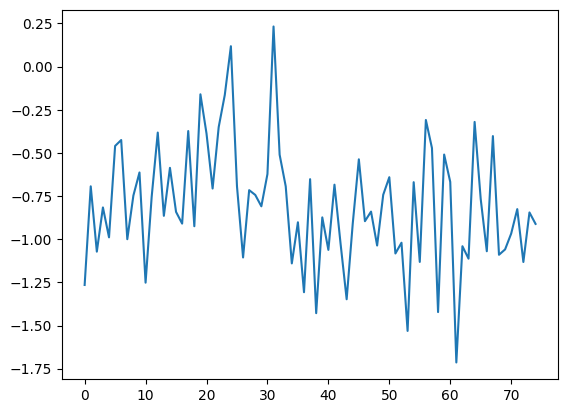

Poisson Neural Network Train Metrics:
MAE: 0.135, MSE: 0.235, L: 0.450

Poisson Neural Network Test Metrics:
MAE: 0.134, MSE: 0.253, L: 0.446



In [ ]:
# Train Poisson feedforward neural network model
torch.manual_seed(2000)


input_dim = X_train_tensor.shape[1]


ADVANCED_POISSON_NN_NH1 = 32
ADVANCED_POISSON_NN_NH2 = 32

N_EPOCHS_ADV_POI_NN = 75
BATCH_SIZE_ADV_POI_NN = 10_000
LEARNING_RATE_ADV_POI_NN = 0.01
MILESTONES_ADV_POI_NN = [75]

N_EPOCHS_ADV_POI_NN_CV = 50 # For CV only train for 50 epochs to speed up!!!

advanced_poisson_nn = AdvancedPoissonNN(input_dim=input_dim, nh1=ADVANCED_POISSON_NN_NH1, nh2=ADVANCED_POISSON_NN_NH2)

ADVANCED_POISSON_NN_MODEL_PATH = f"{MODEL_FOLDER_NAME}/advanced_poisson_nn.pth"

if load_expensive_models:
    advanced_poisson_nn.load_state_dict(ADVANCED_POISSON_NN_MODEL_PATH, map_location="cpu")
    advanced_poisson_nn.eval()
else:
    cv_weight_decay_results = cross_validate_weight_decay(AdvancedPoissonNN, dataset_train, n_folds=3, weight_decay_values=[0.0, 1e-4, 1e-3, 1e-2, 1e-1], 
                                                          n_epochs=N_EPOCHS_ADV_POI_NN_CV, batch_size=BATCH_SIZE_ADV_POI_NN, learning_rate=LEARNING_RATE_ADV_POI_NN, milestones=MILESTONES_ADV_POI_NN)
    best_cv_weight_decay = min(cv_weight_decay_results, key=cv_weight_decay_results.get)
    print(f"Chosen weight_decay: {best_cv_weight_decay}")
    fit_poisson_nn(advanced_poisson_nn, dataset_train, n_epochs=N_EPOCHS_ADV_POI_NN, batch_size=BATCH_SIZE_ADV_POI_NN, learning_rate=LEARNING_RATE_ADV_POI_NN, milestones=MILESTONES_ADV_POI_NN, weight_decay=best_cv_weight_decay, plot_losses=True)
    
    if save_expensive_models:
        torch.save(advanced_poisson_nn.state_dict(), ADVANCED_POISSON_NN_MODEL_PATH)


# Print MAE, MSE and loss on train and test data sets
with torch.no_grad():
    y_pred_train = advanced_poisson_nn(X_train_tensor)
    y_pred_test = advanced_poisson_nn(X_test_tensor)

    poisson_nn_metrics_train = calculate_poisson_metrics(y_train, y_pred_train, exposure_train)
    poisson_nn_metrics_test = calculate_poisson_metrics(y_test, y_pred_test, exposure_test)

    print_poisson_metrics("Poisson Neural Network Train", *poisson_nn_metrics_train)
    print_poisson_metrics("Poisson Neural Network Test", *poisson_nn_metrics_test)

In [50]:
# Make sure your model outperforms the Poisson GLM model of Question 1.b.
if perform_model_comparison:
    glm_nn_differences = []
    torch.manual_seed(2500)
    np.random.seed(2500)
    kf = KFold(n_splits=N_COMPARISONS, shuffle=True)
    differences = []

    print(f"Comparing Feature Engineering Poisson GLM vs Poisson Neural Network using 10-fold CV")

    for fold, (train_idx, test_idx) in enumerate(kf.split(X_train), 1):
        X_kfold_train, X_kfold_test = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_kfold_train, y_kfold_test = y_train.iloc[train_idx], y_train.iloc[test_idx]
        exposure_kfold_train, exposure_kfold_test = exposure_train.iloc[train_idx], exposure_train.iloc[test_idx]


        standardize_one_hot_transformer.fit(X_kfold_train)
        X_kfold_train_transformed = standardize_one_hot_transformer.transform(X_kfold_train).toarray()
        X_kfold_test_transformed = standardize_one_hot_transformer.transform(X_kfold_test).toarray()
        advanced_poisson_nn = AdvancedPoissonNN(input_dim=X_kfold_train_transformed.shape[1])
        dataset_train = TensorDataset(torch.tensor(X_kfold_train_transformed, dtype=torch.float32),
                                      torch.tensor(y_kfold_train.values, dtype=torch.float32),
                                      torch.tensor(exposure_kfold_train.values, dtype=torch.float32))
        fit_poisson_nn(advanced_poisson_nn, dataset_train, n_epochs=N_EPOCHS_ADV_POI_NN, batch_size=BATCH_SIZE_ADV_POI_NN, learning_rate=LEARNING_RATE_ADV_POI_NN, milestones=MILESTONES_ADV_POI_NN)
        

        feature_engineering_poisson_pipeline.fit(X_kfold_train, y_kfold_train, feature_engineering_poisson_glm__sample_weight=exposure_kfold_train)

        advanced_poisson_nn.eval()
        with torch.no_grad():
            poisson_glm_pred_test = poisson_pipeline.predict(X_kfold_test)
            advanced_poisson_nn_pred_test = advanced_poisson_nn(torch.tensor(X_kfold_test_transformed, dtype=torch.float32)).detach().numpy()

            _, _, poisson_deviance_1 = calculate_poisson_metrics(y_kfold_test, poisson_glm_pred_test, exposure_kfold_test)
            _, _, poisson_deviance_2 = calculate_poisson_metrics(y_kfold_test, advanced_poisson_nn_pred_test, exposure_kfold_test)

            print(f"Fold {fold}: {poisson_deviance_1:.4f} vs {poisson_deviance_2:.4f} | Difference = {poisson_deviance_1 - poisson_deviance_2:.4f}")
            glm_nn_differences.append(poisson_deviance_1 - poisson_deviance_2)
        
    print_summarize_differences(glm_nn_differences)  

Comparing Feature Engineering Poisson GLM vs Poisson Neural Network using 10-fold CV


  0%|          | 0/75 [00:00<?, ?it/s]

Fold 1: 0.4649 vs 0.4602 | Difference = 0.0047


  0%|          | 0/75 [00:00<?, ?it/s]

Fold 2: 0.4650 vs 0.4620 | Difference = 0.0030


...

Fold 8: 0.4512 vs 0.4462 | Difference = 0.0049


  0%|          | 0/75 [00:00<?, ?it/s]

Fold 9: 0.4455 vs 0.4430 | Difference = 0.0024


  0%|          | 0/75 [00:00<?, ?it/s]

Fold 10: 0.4682 vs 0.4663 | Difference = 0.0019
Mean Difference: 0.0036, Std Dev: 0.0015, Min: 0.0014, Max: 0.0067


We see that Model 2 (Poisson Neural Network) had 0.0036 (= 0.36%) less exposure-weighted Poisson deviance validation loss (on average), so it is better than the Feature Engineering GLM from 1c).

The weight decay $0.0001$ ($L^2$-regularization) was chosen by cross validation.

We know that the log-loss plot of the NN over the epochs does not look typical, since it is does not improve that much over the epochs. We don't know why, we experimented with many different architectures (less neurons / more neurons, other activation functions) and learning rates (0.0001, 0.001), but we always got similar looking plots. We think that with this data set and architecture, it quite quickly finds a good parameter configuration because even with less epochs, it is already doing quite a good job even on the test data.

# Exercise 3 (Tree-based methods)

### Question 3.a

In [17]:
np.random.seed(3000)
# Implement a regression tree
# Cross-validation

regression_tree_pipeline = Pipeline(
    steps=[
        ("transform", standardize_one_hot_transformer),
        ("regression_tree", tree.DecisionTreeRegressor(criterion="poisson"))
    ]
)

min_impurity_decrease_values = [10**(-k) for k in range(8)] 

param_grid = {"regression_tree__min_impurity_decrease": min_impurity_decrease_values}

regression_tree_grid = GridSearchCV(
    regression_tree_pipeline,
    param_grid,
    scoring="neg_mean_poisson_deviance",
    cv=5,
    n_jobs=-1 # Very important to speed up the grid search
)

REGRESSION_TREE_MODEL_PATH = f"{MODEL_FOLDER_NAME}/regression_tree_model.joblib"
if load_expensive_models:
    regression_tree_grid = joblib.load(REGRESSION_TREE_MODEL_PATH)

else:
    regression_tree_grid.fit(X_train, y_train, regression_tree__sample_weight=exposure_train)
    if save_expensive_models:
        joblib.dump(regression_tree_grid, REGRESSION_TREE_MODEL_PATH)

print(f"Chosen min_impurity_decrease: {regression_tree_grid.best_params_['regression_tree__min_impurity_decrease']}")

Chosen min_impurity_decrease: 0.0001


In [53]:
best_cv_regression_tree_pipeline = regression_tree_pipeline = Pipeline(
    steps=[
        ("transform", standardize_one_hot_transformer),
        ("regression_tree", tree.DecisionTreeRegressor(criterion="poisson", min_impurity_decrease=regression_tree_grid.best_params_['regression_tree__min_impurity_decrease']))
    ]
)

np.random.seed(3500)
performance_difference = compare_models_kfold(feature_engineering_poisson_pipeline, "Poisson GLM Feature Engineering", "feature_engineering_poisson_glm__sample_weight", 
                                              best_cv_regression_tree_pipeline, "Regression Tree", "regression_tree__sample_weight", 
                                              X_train, y_train, exposure_train, n_comparisons=N_COMPARISONS)
print_summarize_differences(performance_difference)

Comparing Poisson GLM Feature Engineering vs Regression Tree using 10-fold CV
Fold 1: 0.4574 vs 0.4556 | Difference = 0.0018
Fold 2: 0.4634 vs 0.4597 | Difference = 0.0037
Fold 3: 0.4625 vs 0.4607 | Difference = 0.0018
Fold 4: 0.4561 vs 0.4524 | Difference = 0.0037
Fold 5: 0.4523 vs 0.4488 | Difference = 0.0035
Fold 6: 0.4534 vs 0.4524 | Difference = 0.0010
Fold 7: 0.4526 vs 0.4504 | Difference = 0.0022
Fold 8: 0.4539 vs 0.4520 | Difference = 0.0020
Fold 9: 0.4564 vs 0.4533 | Difference = 0.0031
Fold 10: 0.4611 vs 0.4587 | Difference = 0.0024
Mean Difference: 0.0025, Std Dev: 0.0009, Min: 0.0010, Max: 0.0037


We see that Model 2 (Poisson Regression Tree) had 0.0025 (= 0.25%) less exposure-weighted Poisson deviance validation loss (on average), so it seems to perform slighlty better as the Feature Engineering GLM from 1c).

In [19]:
# Print MAE, MSE and loss on train and test data sets
y_pred_train = regression_tree_grid.predict(X_train)
y_pred_test = regression_tree_grid.predict(X_test)

regression_tree_metrics_train = calculate_poisson_metrics(y_train, y_pred_train, exposure_train)
regression_tree_metrics_test = calculate_poisson_metrics(y_test, y_pred_test, exposure_test)

print_poisson_metrics("Poisson Regression Tree Train", *regression_tree_metrics_train)
print_poisson_metrics("Poisson Regression Tree Test", *regression_tree_metrics_test)

Poisson Regression Tree Train Metrics:
MAE: 0.137, MSE: 0.236, L: 0.454

Poisson Regression Tree Test Metrics:
MAE: 0.135, MSE: 0.245, L: 0.445



### Question 3.b

In [33]:
# Implement a random forest model
np.random.seed(4000)

# Cross-validation
random_forest_pipeline = Pipeline(
    steps=[
        ("transform", standardize_one_hot_transformer),
        ("random_forest", ensemble.RandomForestRegressor(criterion="poisson"))
    ]
)

min_impurity_decrease_values = [0.0, 0.001, 0.01, 0.1]
max_features_values = ["sqrt", "log2"] + [0.2, 0.4, 0.6, 0.8]


param_grid = {"random_forest__min_impurity_decrease": min_impurity_decrease_values,
              "random_forest__max_features": max_features_values}

random_forest_grid = GridSearchCV(
    random_forest_pipeline,
    param_grid,
    scoring="neg_mean_poisson_deviance",
    cv=5,
    n_jobs=-1 # Very important to speed up the grid search... It still takes multiple hours...
)


RANDOM_FOREST_MODEL_PATH = f"{MODEL_FOLDER_NAME}/random_forest_model.joblib"
if load_expensive_models:
    random_forest_grid = joblib.load(RANDOM_FOREST_MODEL_PATH)

else:
    random_forest_grid.fit(X_train, y_train, random_forest__sample_weight=exposure_train)
    if save_expensive_models:
        joblib.dump(random_forest_grid, RANDOM_FOREST_MODEL_PATH)


In [34]:
print(f"Chosen min_impurity_decrease: {random_forest_grid.best_params_['random_forest__min_impurity_decrease']}, max_features: {random_forest_grid.best_params_['random_forest__max_features']}")
best_min_impurity_decrease = random_forest_grid.best_params_["random_forest__min_impurity_decrease"]
best_max_features = random_forest_grid.best_params_["random_forest__max_features"]

Chosen min_impurity_decrease: 0.0, max_features: log2


In [ ]:
if perform_model_comparison:
    best_cv_random_forest_pipeline = regression_tree_pipeline = Pipeline(
        steps=[
            ("transform", standardize_one_hot_transformer),
            ("random_forest", ensemble.RandomForestRegressor(criterion="poisson", min_impurity_decrease=best_min_impurity_decrease, max_features=best_max_features, n_jobs=-1))
        ]
    )

    np.random.seed(4500)
    performance_difference = compare_models_kfold(feature_engineering_poisson_pipeline, "Poisson GLM Feature Engineering", "feature_engineering_poisson_glm__sample_weight", 
                                                  best_cv_random_forest_pipeline, "Random Forest", "random_forest__sample_weight", 
                                                  X_train, y_train, exposure_train, n_comparisons=N_COMPARISONS)
    print_summarize_differences(performance_difference)

Comparing Poisson GLM Feature Engineering vs Random Forest using 10-fold CV
Fold 1: 0.4572 vs 0.4595 | Difference = -0.0023
Fold 2: 0.4523 vs 0.4555 | Difference = -0.0032
Fold 3: 0.4515 vs 0.4566 | Difference = -0.0051
Fold 4: 0.4429 vs 0.4463 | Difference = -0.0034
Fold 5: 0.4550 vs 0.4576 | Difference = -0.0026
Fold 6: 0.4554 vs 0.4571 | Difference = -0.0016
Fold 7: 0.4658 vs 0.4693 | Difference = -0.0035
Fold 8: 0.4597 vs 0.4617 | Difference = -0.0020
Fold 9: 0.4648 vs 0.4676 | Difference = -0.0028
Fold 10: 0.4648 vs 0.4650 | Difference = -0.0002
Mean Difference: -0.0027, Std Dev: 0.0012, Min: -0.0051, Max: -0.0002


We see that Random had 0.0027 (= 0.27%) **more** exposure-weighted Poisson deviance validation loss (on average), so it performs worse than the Poisson GLM with feature engineering from 1c).
In the next cell we see that it heavily overfitted on the training data, possibly due to chosen `min_impurity_decrease=0.0` (even though this was validated by CV)

In [36]:
# Print MAE, MSE and loss on train and test data sets
y_pred_train = random_forest_grid.predict(X_train)
y_pred_test = random_forest_grid.predict(X_test)

random_forest_metrics_train = calculate_poisson_metrics(y_train, y_pred_train, exposure_train)
random_forest_metrics_test = calculate_poisson_metrics(y_test, y_pred_test, exposure_test)

print_poisson_metrics("Poisson Random Forest Train", *random_forest_metrics_train)
print_poisson_metrics("Poisson Random Forest Test", *random_forest_metrics_test)

Poisson Random Forest Train Metrics:
MAE: 0.130, MSE: 0.214, L: 0.340

Poisson Random Forest Test Metrics:
MAE: 0.139, MSE: 0.249, L: 0.449



### Question 3.c

In [37]:
# Implement gradient boosted trees
np.random.seed(5000)


def to_dense(X):
    return X.toarray()

dense_transformer = FunctionTransformer(to_dense, accept_sparse=True)

# Cross-validation
boosted_trees_pipeline = Pipeline(
    steps=[
        ("transform", standardize_one_hot_transformer),
        ("to_dense", dense_transformer), # GradientBoostingRegressor cannot handle sparse input, which is by default the output of OneHotEncoder
        ("boosted_trees", ensemble.HistGradientBoostingRegressor(loss="poisson")) # HistGradientBoostingRegressor is much faster than GradientBoostingRegressor (according to documentation) and allows 'poisson'-loss
    ]
)

learning_rate_values = [0.001, 0.01, 0.05, 0.1, 0.2]
max_iter_values = [75, 100, 250, 500, 750, 1000]

param_grid = {"boosted_trees__learning_rate": learning_rate_values,
              "boosted_trees__max_iter": max_iter_values}

boosted_trees_grid = GridSearchCV(
    boosted_trees_pipeline,
    param_grid,
    scoring="neg_mean_poisson_deviance",
    cv=5,
    n_jobs=-1 # Very important to speed up the grid search...
)

BOOSTED_TREES_MODEL_PATH = f"{MODEL_FOLDER_NAME}/boosted_trees_model.joblib"
if load_expensive_models:
    boosted_trees_grid = joblib.load(BOOSTED_TREES_MODEL_PATH)

else:
    boosted_trees_grid.fit(X_train, y_train, boosted_trees__sample_weight=exposure_train)
    if save_expensive_models:
        joblib.dump(boosted_trees_grid, BOOSTED_TREES_MODEL_PATH)

print(f"Chosen shrinkage: {boosted_trees_grid.best_params_['boosted_trees__learning_rate']}, number of boosting steps: {boosted_trees_grid.best_params_['boosted_trees__max_iter']}")
best_learning_rate = boosted_trees_grid.best_params_["boosted_trees__learning_rate"]
best_max_iter = boosted_trees_grid.best_params_["boosted_trees__max_iter"]

Chosen shrinkage: 0.01, number of boosting steps: 250


In [38]:
# Print MAE, MSE and loss on train and test data sets
y_pred_train = boosted_trees_grid.predict(X_train)
y_pred_test = boosted_trees_grid.predict(X_test)

boosted_trees_metrics_train = calculate_poisson_metrics(y_train, y_pred_train, exposure_train)
boosted_trees_metrics_test = calculate_poisson_metrics(y_test, y_pred_test, exposure_test)

print_poisson_metrics("Poisson Boosted Tree Train", *boosted_trees_metrics_train)
print_poisson_metrics("Poisson Boosted Tree Test", *boosted_trees_metrics_test)

Poisson Boosted Tree Train Metrics:
MAE: 0.137, MSE: 0.235, L: 0.446

Poisson Boosted Tree Test Metrics:
MAE: 0.135, MSE: 0.244, L: 0.439



In [ ]:
if perform_model_comparison:
    dense_transformer = FunctionTransformer(lambda x: x.toarray(), accept_sparse=True)
    best_cv_boosted_trees_pipeline = regression_tree_pipeline = Pipeline(
        steps=[
            ("transform", standardize_one_hot_transformer),
            ("to_dense", dense_transformer), # GradientBoostingRegressor cannot handle sparse input, which is by default the output of OneHotEncoder, so we need a dense transformer
            ("boosted_trees", ensemble.HistGradientBoostingRegressor(loss="poisson", learning_rate=best_learning_rate, max_iter=best_max_iter))
        ]
    )

    np.random.seed(5500)
    performance_difference = compare_models_kfold(feature_engineering_poisson_pipeline, "Poisson GLM Feature Engineering", "feature_engineering_poisson_glm__sample_weight", 
                                                  best_cv_boosted_trees_pipeline, "Boosted Tree", "boosted_trees__sample_weight", 
                                                  X_train, y_train, exposure_train, n_comparisons=N_COMPARISONS)
    print_summarize_differences(performance_difference)

Comparing Poisson GLM Feature Engineering vs Boosted Tree using 10-fold CV
Fold 1: 0.4542 vs 0.4463 | Difference = 0.0079
Fold 2: 0.4583 vs 0.4505 | Difference = 0.0078
Fold 3: 0.4594 vs 0.4514 | Difference = 0.0080
Fold 4: 0.4561 vs 0.4480 | Difference = 0.0081
Fold 5: 0.4669 vs 0.4578 | Difference = 0.0091
Fold 6: 0.4510 vs 0.4446 | Difference = 0.0064
Fold 7: 0.4576 vs 0.4490 | Difference = 0.0086
Fold 8: 0.4574 vs 0.4507 | Difference = 0.0067
Fold 9: 0.4382 vs 0.4316 | Difference = 0.0066
Fold 10: 0.4701 vs 0.4607 | Difference = 0.0094
Mean Difference: 0.0079, Std Dev: 0.0010, Min: 0.0064, Max: 0.0094


We see that the Boosted Tree had 0.0079 (= 0.79%) less exposure-weighted Poisson deviance validation loss (on average), which suggests that it is much better than the Feature Engineering Poisson GLM from 1c).

This is by far the highest performance increase that we have seen. So the gradient boosted tree was the best model for our modelling task.

# Overall Performance

Here we summarize the exposure weighted Poisson deviance performances of the models:

|                         | Train $L$ | Test $L$ |
| ----------------------- | --------- | -------- |
| Simple GLM              | 0.459     | 0.452    |
| Feature Engineering GLM | 0.456     | 0.448    |
| Neural Network          | 0.450     | 0.446    |
| Regression Tree         | 0.454     | 0.445    |
| Random Forest           | 0.340     | 0.449    |
| Boosted Tree            | 0.446     | 0.439    |

This table matches what we saw in terms of 10 fold cross validation performance comparison (on the training data):<br>
The boosted tree was by far the best model in terms of performance on the test set. The regression tree was quite poor in generalizing because it was overfit to the training data.
The neural network performed slightly better than the feature engineering GLM which itself performed better than the simple GLM that was fit in 1a).
